## MMFI 데이터 구조 뜯어보기 CSI 부분만 

In [3]:
from scipy.io import loadmat

data = loadmat("frame001.mat")

print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'CSIamp', 'CSIphase'])


In [4]:
print(data)

{'__header__': b'MATLAB 5.0 MAT-file Platform: posix, Created on: Mon Nov 21 16:26:18 2022', '__version__': '1.0', '__globals__': [], 'CSIamp': array([[[42.36587641, 41.13809703, 44.68288239, ..., 41.76814481,
         41.15444083, 40.33584576],
        [42.75380468, 42.15082115, 44.74391113, ..., 42.39249413,
         41.2169113 , 40.76276255],
        [43.57267655, 42.37065953, 46.33811716, ..., 43.4754467 ,
         42.41546481, 41.78401342],
        ...,
        [44.93834323, 44.42871555, 46.77771151, ..., 44.97220003,
         43.34634669, 42.82304828],
        [44.5359351 , 43.55796214, 46.5089978 , ..., 44.11434502,
         43.19730494, 43.06253421],
        [43.92784858, 42.83527365, 45.99664779, ..., 43.67616792,
         42.6599637 , 42.21283799]],

       [[43.84120342, 43.20831473, 43.86695112, ..., 43.72359583,
         43.16808752, 43.38635752],
        [44.18052578, 43.79196704, 44.16057729, ..., 44.11434502,
         43.73739318, 43.74161561],
        [44.86430479, 44.

#### 복소수 채널 행렬


In [5]:
import numpy as np

csi_complex = data["CSIamp"] * np.exp(
    1j * data["CSIphase"]
)

print(csi_complex.shape)

(3, 114, 10)


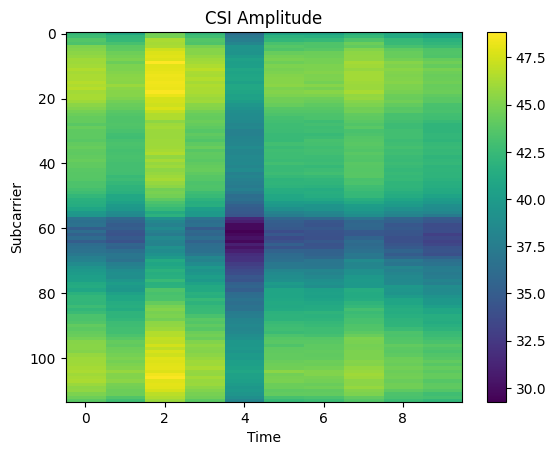

In [6]:
import matplotlib.pyplot as plt

plt.imshow(data["CSIamp"][0], aspect='auto')
plt.colorbar()
plt.title("CSI Amplitude")
plt.xlabel("Time")
plt.ylabel("Subcarrier")
plt.show()

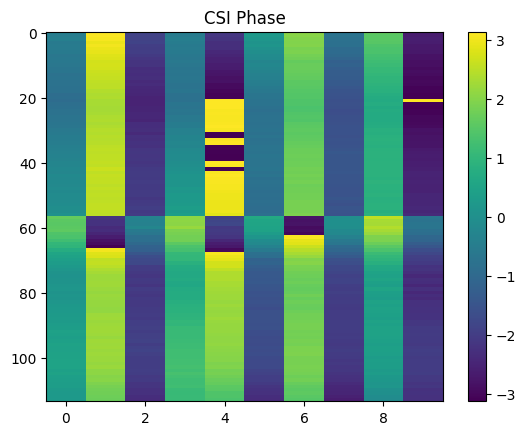

In [7]:
plt.imshow(data["CSIphase"][0], aspect='auto')
plt.colorbar()
plt.title("CSI Phase")
plt.show()

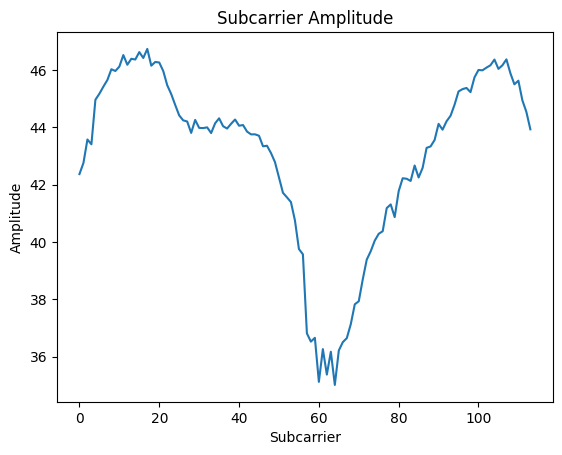

In [8]:
import matplotlib.pyplot as plt

plt.plot(data["CSIamp"][0, :, 0])
plt.title("Subcarrier Amplitude")
plt.xlabel("Subcarrier")
plt.ylabel("Amplitude")
plt.show()

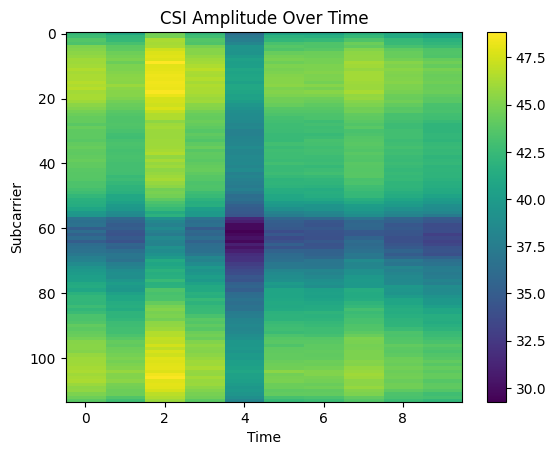

In [9]:
plt.imshow(data["CSIamp"][0], aspect='auto')
plt.colorbar()
plt.title("CSI Amplitude Over Time")
plt.xlabel("Time")
plt.ylabel("Subcarrier")
plt.show()

#### 정답지 테스트 

#### 정답지 라벨 , Train 라벨 수량 확인 

In [19]:
import numpy as np

gt = np.load("E01/S01/A02/ground_truth.npy")

print(gt.shape)
print("한개의 대한 정답지 \n" , gt[0])
print(type(gt))
print(gt.dtype)

(297, 17, 3)
한개의 대한 정답지 
 [[-0.06256401 -0.03782858  3.3111265 ]
 [-0.17242302 -0.03946598  3.3111265 ]
 [-0.17860788  0.36894196  3.3082628 ]
 [-0.20258439  0.7604647   3.3111265 ]
 [ 0.04729501 -0.03619118  3.3111265 ]
 [ 0.06333054  0.36894196  3.3111265 ]
 [ 0.06733828  0.7604647   3.3111265 ]
 [-0.06055941 -0.33014497  3.2906113 ]
 [-0.05855481 -0.6224614   3.270096  ]
 [-0.05382076 -0.73319846  3.2078774 ]
 [-0.05686413 -0.7927881   3.2421067 ]
 [ 0.10305467 -0.5670928   3.3010175 ]
 [ 0.34466282 -0.5170928   3.261518  ]
 [ 0.30620605 -0.5670108   3.0210314 ]
 [-0.22489834 -0.5670928   3.3013933 ]
 [-0.46679878 -0.5170928   3.2619116 ]
 [-0.42772546 -0.56652963  3.0203378 ]]
<class 'numpy.ndarray'>
float32


* 요거 하나하나가 관절 포인트라 함 

In [17]:
import os
import numpy as np
from scipy.io import loadmat

folder = "E01/S01/A01/wifi-csi"

files = sorted(os.listdir(folder))

csi_list = []

for file in files:

    path = os.path.join(folder, file)

    data = loadmat(path)

    amp = data["CSIamp"]
    phase = data["CSIphase"]

    csi_complex = amp * np.exp(
        1j * phase
    )

    csi_list.append(csi_complex)

csi_tensor = np.array(csi_list)

print(csi_tensor.shape)

C:\Users\yujaerim\AppData\Local\Temp\ipykernel_18700\2840366826.py:20: RuntimeWarning: invalid value encountered in multiply
  csi_complex = amp * np.exp(


(297, 3, 114, 10)


* 일단 데이터 수가 동일한건 확인됨 